# Cellpose on Registered Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from cellpose import models, core
from mbo_utilities import imread
import lbm_suite2p_python as lsp

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Run registration only (no detection)

In [6]:
RAW_PATH = Path(r"D:/cj/2025-11-21/raw/vdaq1")
OUTPUT_DIR = Path(r"D:/cj/2025-11-21/cellpose")

# Registration only, no ROI detection
ops_paths = lsp.pipeline(
    input_data=RAW_PATH,
    save_path=OUTPUT_DIR,
    planes=[1],  # First plane only
    force_reg=False,
    force_detect=False,
)

print(f"Results: {ops_paths}")

Loading input data...
  Input: D:\cj\2025-11-21\raw\vdaq1


Counting frames:   0%|          | 0/1 [00:00<?, ?it/s]

  Loaded as: MboRawArray

Dataset info:
  Shape: (970, 2, 772, 735)
  Frames: 970
  Planes: 2
  Dimensions: 772 x 735
  Phase correction: True
  FFT subpixel: False
  Frame rate: 5.40 Hz
  ROIs: 5
Importing suite2p packages...

Processing plan:
  Planes: [1]
  Output: D:\cj\2025-11-21\cellpose

Processing plane 1/2
  Writing binary (970 frames, 772x735)...


Saving data_raw.bin:   0%|          | 0/105 [00:00<?, ?it/s]

No pixel resolution found in metadata, using default [2, 2].


  Running Suite2p pipeline...
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 14.19 sec.
Registered 500/970 in 17.07s
Registered 970/970 in 33.20s
----------- Total 51.30 sec
----------- ROI DETECTION
Binning movie in chunks of length 07


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie of size [138,772,735] created in 1.05 sec.
>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 6.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is deprecated in v4.0.1+


>>>> 317 masks detected, median diameter = 13.91 
Detected 317 ROIs, 15.66 sec
After removing overlaps, 317 ROIs remain
----------- Total 17.29 sec.
----------- EXTRACTION
Masks created, 1.60 sec.
Extracted fluorescence from 317 ROIs in 970 frames, 5.78 sec.
----------- Total 7.39 sec.
----------- CLASSIFICATION
['compact', 'npix_norm', 'skew']
----------- SPIKE DECONVOLUTION
----------- Total 0.01 sec.
  Computing dF/F...
  Generating plots...
Plotting results for 197 accepted / 120 rejected ROIs
  Completed plane01_stitched in 87.5s

Pipeline complete!
  Processed: 1 planes
  Time: 87.5s
  Output: D:\cj\2025-11-21\cellpose
Results: [WindowsPath('D:/cj/2025-11-21/cellpose/plane01_stitched/ops.npy')]


## Load max_proj and run Cellpose

In [3]:
# Load ops from registration
ops_path = ops_paths[0]
ops = np.load(ops_path, allow_pickle=True).item()
max_proj = ops["max_proj"].astype(np.float32)
Ly, Lx = ops["Ly"], ops["Lx"]

print(f"Loaded max_proj: {Ly}x{Lx}")

Loaded max_proj: 772x735


In [4]:
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

# Best params from debug_lsp_pipeline: d=2, spa=0
DIAMETER = 4
CELLPROB_THRESHOLD = -6.0

model = models.CellposeModel(gpu=core.use_gpu())
img = normalize99(max_proj)

masks, flows, styles = model.eval(
    img,
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_THRESHOLD,
    flow_threshold=0.0,
)

n_cells = masks.max()
print(f"Detected {n_cells} cells")

Resizing is deprecated in v4.0.1+


Detected 657 cells


## Visualize

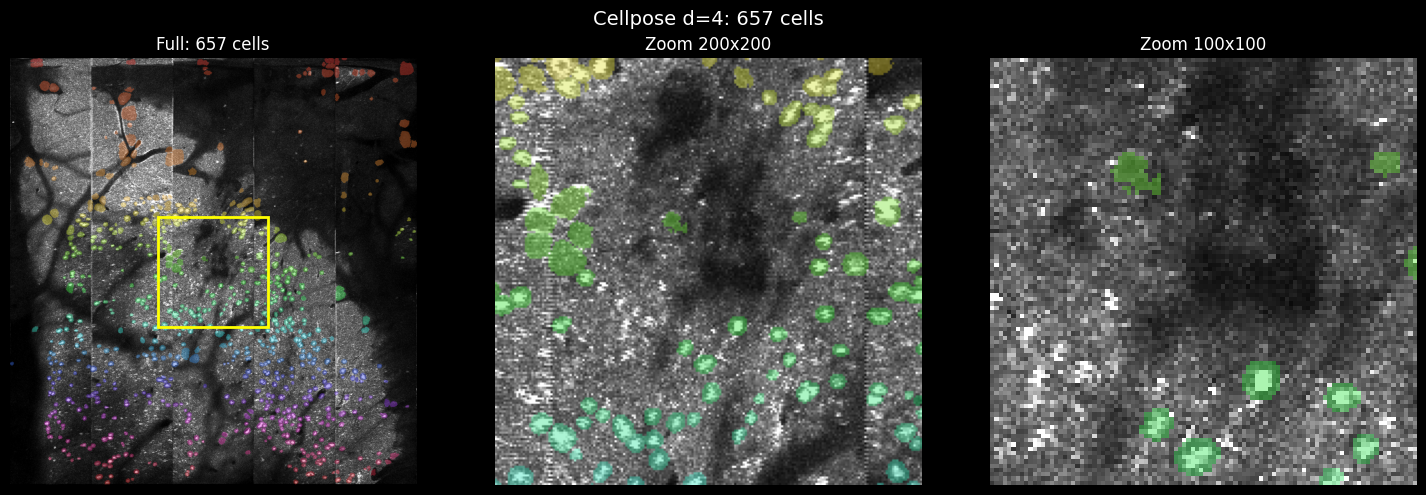

In [5]:
def mask_overlay(img, masks, alpha=0.4):
    from matplotlib.colors import hsv_to_rgb
    img_norm = normalize99(img)
    rgb = np.stack([img_norm]*3, axis=-1)
    if masks.max() > 0:
        n = masks.max()
        colors = np.zeros((n+1, 3))
        for i in range(1, n+1):
            colors[i] = hsv_to_rgb([i/n, 0.8, 0.9])
        mask_rgb = colors[masks]
        mask_area = masks > 0
        rgb[mask_area] = (1-alpha)*rgb[mask_area] + alpha*mask_rgb[mask_area]
    return np.clip(rgb, 0, 1)

cy, cx = Ly // 2, Lx // 2
zs = 200

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

overlay = mask_overlay(max_proj, masks)
axes[0].imshow(overlay)
axes[0].add_patch(plt.Rectangle((cx-zs//2, cy-zs//2), zs, zs, fill=False, edgecolor="yellow", linewidth=2))
axes[0].set_title(f"Full: {n_cells} cells")
axes[0].axis("off")

y1, y2 = cy - zs//2, cy + zs//2
x1, x2 = cx - zs//2, cx + zs//2
axes[1].imshow(overlay[y1:y2, x1:x2])
axes[1].set_title(f"Zoom {zs}x{zs}")
axes[1].axis("off")

zs2 = 100
y1, y2 = cy - zs2//2, cy + zs2//2
x1, x2 = cx - zs2//2, cx + zs2//2
axes[2].imshow(overlay[y1:y2, x1:x2])
axes[2].set_title(f"Zoom {zs2}x{zs2}")
axes[2].axis("off")

plt.suptitle(f"Cellpose d={DIAMETER}: {n_cells} cells", fontsize=14)
plt.tight_layout()
plt.show()